In [29]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [30]:
import os
import warnings
warnings.filterwarnings("ignore", message = ".Glyph.*")
import gc, json, random, shutil, subprocess, sys, time
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import font_manager
from PIL import Image

QUICK = True

BASE = Path.cwd()

ASSETS = BASE / "assets" / "assets"
DATA = BASE / "data" / "data" / "knowledge"
WORK = BASE / "work"
for d in ('models', 'chroma', 'images'):
    (WORK / d).mkdir(parents = True, exist_ok = True)

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else: 
    DEVICE = 'cpu'

IMG_TYPE = torch.float16 if DEVICE in ('cuda', 'mps') else torch.float32

installed = {f.name for f in font_manager.fontManager.ttflist}
for name in ('Malgun Gothic', 'NanumGothic'):
    if name in installed:
        plt.rcParams['font.family'] = name
        break
plt.rcParams['axes.unicode_minus'] = False

In [31]:
def set_seed(seed = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def free_memory():
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

def show_images(images, titles = None, cols = None, size = 3.2):
    cols = cols or len(images)
    rows = (len(images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize = (size * cols, size * rows), squeeze = False)
    for ax in axes.ravel(): ax.axis('off')
    for i, im in enumerate(images):
        axes.ravel()[i].imshow(im)
        if titles: axes.ravel()[i].set_title(titles[i], fontsize = 10)
    plt.tight_layout(); plt.show()

set_seed(42)
print(DEVICE, QUICK)
print(BASE)

cuda True
c:\Users\KDS23\Documents\17-KDT\17-RAG


In [32]:
from transformers import AutoTokenizer, AutoModel

EMB_NAME = 'intfloat/multilingual-e5-small'
tok = AutoTokenizer.from_pretrained(EMB_NAME)
emb_model = AutoModel.from_pretrained(EMB_NAME).eval().to(DEVICE)

sentences = ['나는 유정이를 사랑합니다.', '오늘만 쉬면 3일 연휴가 2개입니다.']
enc = tok(sentences, padding = True, truncation = True, return_tensors = 'pt')

print(enc['input_ids'])
for i in range(len(sentences)):
    print(tok.convert_ids_to_tokens(enc['input_ids'][i]))
print(enc['attention_mask'])

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3038.64it/s]


tensor([[    0, 37231,  5241,  2905,   469,   688, 40434,  8642,     5,     2,
             1,     1,     1,     1,     1,     1],
        [    0, 42742,  3184,     6, 48637,  4253,   138,  1599, 11573, 95174,
           713,   116,  6027,  5826,     5,     2]])
['<s>', '▁나는', '▁유', '정', '이', '를', '▁사랑', '합니다', '.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
['<s>', '▁오늘', '만', '▁', '쉬', '면', '▁3', '일', '▁연', '휴', '가', '▁2', '개', '입니다', '.', '</s>']
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


In [33]:
with torch.no_grad():
    out = emb_model(**enc.to(DEVICE))

emb = out.last_hidden_state

print(tuple(emb.shape))
print(emb[0, 0, :3].cpu().numpy().round(3))

(2, 16, 384)
[ 0.21  -0.082 -0.179]


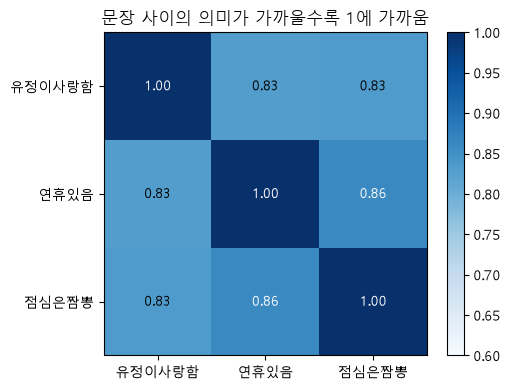

In [34]:
import torch.nn.functional as F


def embed(texts, prefix="query: ", batch_size=32):
    vectors = []

    for i in range(0, len(texts), batch_size):
        batch = [
            prefix + text
            for text in texts[i:i + batch_size]
        ]

        enc = tok(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            hidden = emb_model(**enc).last_hidden_state

        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)

        vectors.append(
            F.normalize(pooled, p=2, dim=1).cpu()
        )

    return torch.cat(vectors, dim=0)


test = [
    "나는 유정이를 사랑합니다.",
    "오늘만 쉬면 3일 연휴가 2개입니다.",
    "오늘의 점심은 짬뽕입니다."
]

vecs = embed(test)
sim = vecs @ vecs.T

labels = [
    "유정이사랑함",
    "연휴있음",
    "점심은짬뽕"
]

fig, ax = plt.subplots(figsize=(5.2, 4))

im = ax.imshow(
    sim.numpy(),
    cmap="Blues",
    vmin=0.6,
    vmax=1.0
)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))

# 문자열 3개가 아니라 리스트 하나를 전달
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        value = sim[i, j].item()

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if value > 0.85 else "black"
        )

ax.set_title("문장 사이의 의미가 가까울수록 1에 가까움")

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [35]:
from torchvision import transforms, models

img = Image.open(ASSETS / 'puppy.jpg').convert('RGB')
x = transforms.ToTensor()(img)

weights = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights = weights).eval()
labels = weights.meta['categories']

batch = weights.transforms()(img).unsqueeze(0)

with torch.no_grad():
    logits = resnet(batch)

probs = torch.softmax(logits, dim = 1)[0]
top_p, top_i = probs.topk(5)

for p, i in zip(top_p, top_i):
    print(f'{labels[i]:25s} {p:6.1%}')

entropy = -(probs * torch.log(probs + 1e-10)).sum()

Labrador retriever         23.9%
Sealyham terrier           18.3%
tennis ball                11.6%
Great Pyrenees             11.6%
golden retriever            7.6%


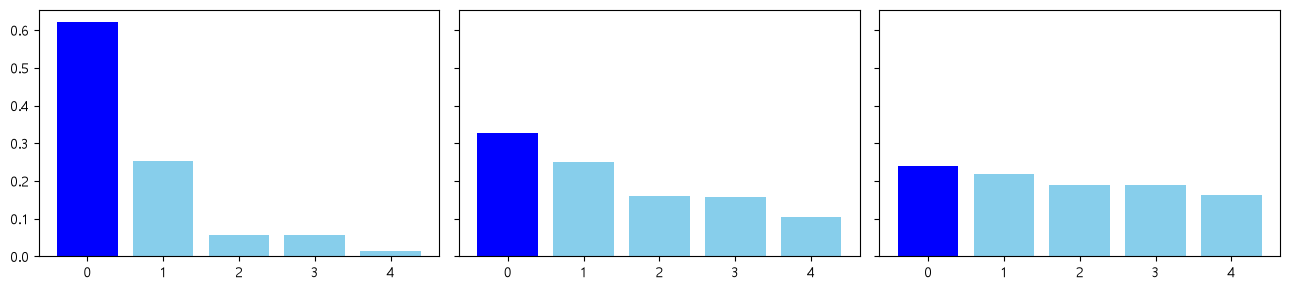

In [37]:
top_logits = logits[0].topk(5).values
fig, axes = plt.subplots(1, 3, figsize = (13,3), sharey = True)

for ax, T in zip(axes, (0.3, 1.0, 3.0)):
    p = torch.softmax(top_logits / T, dim = 0)
    ax.bar(range(5), p.numpy(), color = ['blue'] + ['skyblue'] * 4)
plt.tight_layout(); plt.show()

In [39]:
from huggingface_hub import HfApi, hf_hub_download, ModelCard

api = HfApi()
try:
    info = api.model_info(EMB_NAME)
    print(info.id)
    print(info.pipeline_tag)
    print(info.downloads)
    print(info.tags)
    for m in api.list_models(filter = 'text-classification', sort = 'downloads', limit = 5):
        print(m.id)

except Exception as e:
    print('Failed')

intfloat/multilingual-e5-small
sentence-similarity
11814750
['sentence-transformers', 'pytorch', 'onnx', 'safetensors', 'openvino', 'bert', 'mteb', 'Sentence Transformers', 'sentence-similarity', 'multilingual', 'af', 'am', 'ar', 'as', 'az', 'be', 'bg', 'bn', 'br', 'bs', 'ca', 'cs', 'cy', 'da', 'de', 'el', 'en', 'eo', 'es', 'et', 'eu', 'fa', 'fi', 'fr', 'fy', 'ga', 'gd', 'gl', 'gu', 'ha', 'he', 'hi', 'hr', 'hu', 'hy', 'id', 'is', 'it', 'ja', 'jv', 'ka', 'kk', 'km', 'kn', 'ko', 'ku', 'ky', 'la', 'lo', 'lt', 'lv', 'mg', 'mk', 'ml', 'mn', 'mr', 'ms', 'my', 'ne', 'nl', 'no', 'om', 'or', 'pa', 'pl', 'ps', 'pt', 'ro', 'ru', 'sa', 'sd', 'si', 'sk', 'sl', 'so', 'sq', 'sr', 'su', 'sv', 'sw', 'ta', 'te', 'th', 'tl', 'tr', 'ug', 'uk', 'ur', 'uz', 'vi', 'xh', 'yi', 'zh', 'arxiv:2402.05672', 'arxiv:2108.08787', 'arxiv:2104.08663', 'arxiv:2210.07316', 'license:mit', 'model-index', 'eval-results', 'text-embeddings-inference', 'endpoints_compatible', 'region:us']
cross-encoder/ms-marco-MiniLM-L6-v2
BA